<a href="https://colab.research.google.com/github/IanPerigoUERN/NexVisual/blob/main/NexVisual_Desafio_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Reconhecimento Facial**

In [1]:
!pip install opencv-python matplotlib imutils tqdm ipywidgets scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 49.6 MB/s eta 0:00:00


In [3]:
import cv2
import matplotlib.pyplot as plt
import os
import imutils.paths as paths
import imutils
import pickle
import numpy as np
from tqdm.notebook import tqdm
import sklearn
from google.colab import drive
from google.colab.patches import cv2_imshow

In [11]:
drive.mount ('/content/drive')

directory = '/content/drive/MyDrive/nexvisual_files/Desafio2'

os.makedirs(directory, exist_ok=True)



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [13]:
protoPath = os.path.join(directory, "face_detection_model", "deploy.prototxt")
modelPath = os.path.join(directory, "face_detection_model", "res10_300x300_ssd_iter_140000.caffemodel")

# Check if the files exist before attempting to load them
if not os.path.exists(protoPath):
    print(f"Error: deploy.prototxt not found at {protoPath}")
if not os.path.exists(modelPath):
    print(f"Error: res10_300x300_ssd_iter_140000.caffemodel not found at {modelPath}")

detector = cv2.dnn.readNetFromCaffe(protoPath, modelPath)

embedderPath = os.path.join(
    directory,
    "face_detection_model",
    "openface_nn4.small2.v1.t7"
)

embedder = cv2.dnn.readNetFromTorch(embedderPath)

In [35]:
#dataset directory

dataset_dir = os.path.join(directory, "dataset")

# Captura os paths do dataset
imagePaths = list(paths.list_images(dataset_dir))



# Lista de caracteristicas e nomes
knownEmbeddings = []
knownNames = []
print(dataset_dir)

/content/drive/MyDrive/nexvisual_files/Desafio2/dataset


In [37]:
# Carregar os modelos.
# Use os.path.join with the 'directory' variable for correct paths in Google Drive
protoPath = os.path.join(directory, "face_detection_model", "deploy.prototxt")
modelPath = os.path.join(directory, "face_detection_model", "res10_300x300_ssd_iter_140000.caffemodel")
detector = cv2.dnn.readNetFromCaffe(protoPath, modelPath)

embedderPath = os.path.join(
    directory,
    "face_detection_model",
    "openface_nn4.small2.v1.t7"
)
embedder = cv2.dnn.readNetFromTorch(embedderPath)

# Captura os paths do dataset
# Use the 'dataset_dir' variable for correct paths to the dataset images
imagePaths = list(paths.list_images(dataset_dir))

# Lista de caracteristicas e nomes
knownEmbeddings = []
knownNames = []


# loop sobre as imagens do dataset
for imagePath in tqdm(imagePaths):
    name = imagePath.split(os.path.sep)[-2] # Captura nomes dos dataset
    image = cv2.imread(imagePath) # Le imagem

    # It's good practice to check if the image was loaded successfully
    if image is None:
        print(f"Warning: Could not load image {imagePath}. Skipping.")
        continue

    image = imutils.resize(image, width=600) # Redimensiona imagem
    (h, w) = image.shape[:2] # Pega dimensões da imagem

    # OpenCV pre processamento para modelos de deep learning
    imageBlob = cv2.dnn.blobFromImage(
        cv2.resize(image, (300, 300)), 1.0, (300, 300),
        (104.0, 177.0, 123.0), swapRB=False, crop=False)
    detector.setInput(imageBlob) # Define entrada do modelo de deep learning
    detections = detector.forward() # Processa a imagem

    # Valida que pelo menos 1 face foi detectada na iamgem
    if len(detections) > 0:
        # Assumindo apenas 1 face por imagem, pegamos a maior bounding box
        # E validamos que aquela detecção está dentro do limite de 50% de confiança
        i = np.argmax(detections[0, 0, :, 2])
        confidence = detections[0, 0, i, 2]
        if confidence > 0.5:
            # Calcular as coordenadas da bounding box
            box = detections[0, 0, i, 3:7] * np.array([w, h, w, h])
            (startX, startY, endX, endY) = box.astype("int")
            # Extrair a imagem da face
            face = image[startY:endY, startX:endX]
            (fH, fW) = face.shape[:2]
            # Valida que a imagem da face é grande o suficiente
            if fW < 20 or fH < 20:
                print(f"Warning: Face in {imagePath} is too small ({fW}x{fH}). Skipping.")
                continue
            # Additional check for empty face array
            if face.size == 0:
                print(f"Warning: Extracted face region is empty for {imagePath}. Skipping.")
                continue


            # OpenCV pre processamento para imagem da face
            faceBlob = cv2.dnn.blobFromImage(face, 1.0 / 255,
                    (96, 96), (0, 0, 0), swapRB=True, crop=False)
            embedder.setInput(faceBlob) # Define como entrada do modelo de extração de características
            vec = embedder.forward() # Processa a imagem

            # Adiciona as listas o nome e as características
            knownNames.append(name)
            knownEmbeddings.append(vec.flatten())
    else:
        print(f"Warning: No faces detected in {imagePath}. Skipping.")

# Salva arquivo.
# Ensure output directory and file are saved within the Google Drive 'directory'
output_dir = os.path.join(directory, "output")
os.makedirs(output_dir, exist_ok=True)
data = {"embeddings": knownEmbeddings, "names": knownNames}
f = open(os.path.join(output_dir, "embeddings.pickle"), "wb")
f.write(pickle.dumps(data))
f.close()

  0%|          | 0/21 [00:00<?, ?it/s]

In [41]:
# Define the output directory (same as in Rl4Gy6CbtZVm) to load/save files
output_dir = os.path.join(directory, "output")
os.makedirs(output_dir, exist_ok=True)

# Carrega os dados de características
# Ensure embeddings.pickle is loaded from the correct output_dir
data = pickle.loads(open(os.path.join(output_dir, "embeddings.pickle"), "rb").read())

# Cria o pre processamento e define os labels como os nomes
le = sklearn.preprocessing.LabelEncoder()
labels = le.fit_transform(data["names"])

# Cria um modelo de SVM para classificar usando as características
recognizer = sklearn.svm.SVC(C=1.0, kernel="linear", probability=True)
recognizer.fit(data["embeddings"], labels)


# Salva os modelos de classificação (reconhecimento) e de labels
# Ensure recognizer.pickle and le.pickle are saved to the correct output_dir
f = open(os.path.join(output_dir, "recognizer.pickle"), "wb")
f.write(pickle.dumps(recognizer))
f.close()
f = open(os.path.join(output_dir, "le.pickle"), "wb")
f.write(pickle.dumps(le))
f.close()

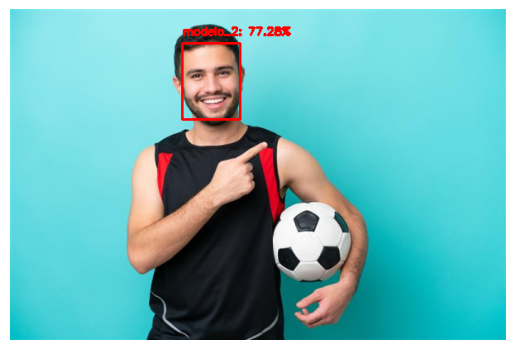

In [46]:
########################
## Processar o Modelo ##
########################

# Define a image de teste
# Construct the full path to the test image using the 'directory' variable
image_to_test_path = os.path.join(directory, "test", "modelo_2_2.jpeg")

# Carrega os modelos
protoPath = os.path.join(directory, "face_detection_model", "deploy.prototxt")
modelPath = os.path.join(directory, "face_detection_model", "res10_300x300_ssd_iter_140000.caffemodel")
detector = cv2.dnn.readNetFromCaffe(protoPath, modelPath)

embedderPath = os.path.join(
    directory,
    "face_detection_model",
    "openface_nn4.small2.v1.t7"
)
embedder = cv2.dnn.readNetFromTorch(embedderPath)

# Define the output directory to load saved models
output_dir = os.path.join(directory, "output")
recognizer = pickle.loads(open(os.path.join(output_dir, "recognizer.pickle"), "rb").read())
le = pickle.loads(open(os.path.join(output_dir, "le.pickle"), "rb").read())

# Carrega a imagem
image = cv2.imread(image_to_test_path)

# It's good practice to check if the image was loaded successfully
if image is None:
    print(f"Error: Could not load test image from {image_to_test_path}. Please ensure the file exists.")
    # Optionally, you can raise an error or exit here if the image is critical
    # For now, we'll just skip the rest of the processing for this image
else:
    image = imutils.resize(image, width=600) # Redimensiona a imagem
    (h, w) = image.shape[:2] # Salva as dimensões
    # Pre processa por OpenCV para modelo de deep learning
    # Pré-processa para o detector facial
    imageBlob = cv2.dnn.blobFromImage(
        cv2.resize(image, (300, 300)),
        1.0,
        (300, 300),
        (104.0, 177.0, 123.0)
    )
    # Detecta faces na imagem de input
    detector.setInput(imageBlob)
    detections = detector.forward()


    # loop sobre as detecções
    for i in range(0, detections.shape[2]):
        confidence = detections[0, 0, i, 2] # Valida a confiaça da detecção que estpa sendo iterada
        # Valida que a detecção tem uma confiança superior a 50%
        if confidence > 0.5:
            # Calcula coordenadas da face
            box = detections[0, 0, i, 3:7] * np.array([w, h, w, h])
            (startX, startY, endX, endY) = box.astype("int")
            # Extrai imagem da face
            face = image[startY:endY, startX:endX]
            (fH, fW) = face.shape[:2]
            # Garante o tamanho da imagem da face não é pequeno demais
            if fW < 20 or fH < 20:
                continue

            # OpenCV pre processamento para o modelo de extração de características
            faceBlob = cv2.dnn.blobFromImage(
              face,
              scalefactor=1.0 / 255,
              size=(96, 96),
              mean=(0, 0, 0),
              swapRB=True,
              crop=False
          )
            embedder.setInput(faceBlob) # Define o input do modelo de extração de características
            vec = embedder.forward()

            # Realiza a classificação com o modelo de reconhecimento
            preds = recognizer.predict_proba(vec)[0]
            j = np.argmax(preds) # Pega o indice da maior probabilidade
            proba = preds[j] # Salva o valor da maior probabilidade
            name = le.classes_[j] # Recupera o nome da maior probabilidade

            # Desenha um retângulo com o texto do nome e da probabilidade na face reconhecida
            text = "{}: {:.2f}%".format(name, proba * 100)
            y = startY - 10 if startY - 10 > 10 else startY + 10
            cv2.rectangle(image, (startX, startY), (endX, endY),
                (0, 0, 255), 2)
            cv2.putText(image, text, (startX, y),
                cv2.FONT_HERSHEY_SIMPLEX, 0.45, (0, 0, 255), 2)

    # Display the image with detections
    # Changed to display the 'image' variable which has the drawn bounding boxes
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.show()